In [10]:
from cellmender.simulation import simulate_cells
import cellmender.utils as cm_utils
from cellmender import denoise_count_matrix
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
import os

cellmender_dir = os.path.dirname(os.path.abspath(""))
out_dir = os.path.join(cellmender_dir, "notebooks", "output", "debug_sim")

In [11]:
data = simulate_cells(G = 2000, N = 5000, dispersion = 1, alpha = 1e-4, beta = 0.5)
print(data)

AnnData object with n_obs × n_vars = 5000 × 2000
    obs: 'celltype', 'is_empty', 'ambient_fraction', 'lib_size'
    var: 'ambient_profile', 'is_marker'
    uns: 'simulation_params', 'marker_sets', 'type_profiles'
    layers: 'noise', 'real'


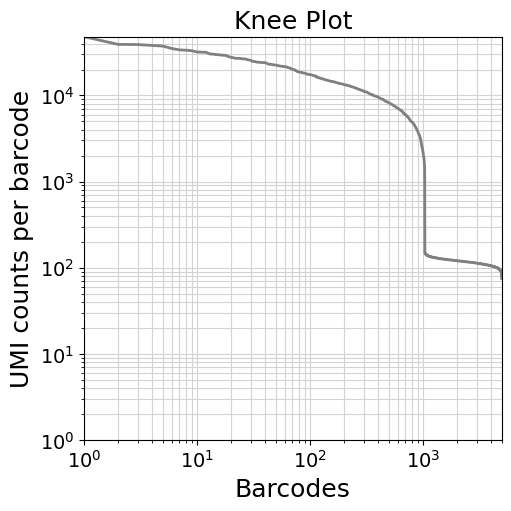

In [12]:
cm_utils.knee_plot(data)

In [13]:
adata_cellmender_path = os.path.join(out_dir, "adata_cellmender.h5ad")
adata_log_path = os.path.join(out_dir, "cellmender.log")
denoised_data = denoise_count_matrix(data, max_iter=150, beta=0.03, eps=1e-9, cell_ambient_fraction=0.01, verbose=2, adata_out = adata_cellmender_path, log_file = adata_log_path)

10:38:34 - INFO - Added 'ambient_fraction' to adata.var.
10:38:34 - INFO - adata.uns does not have 'celltype_profile'. Inferring cell type profiles using infer_celltype_profile().
10:38:34 - INFO - Number of parameters in the cellmender model: 21,288 (alpha_i: 1,041, beta: 1, gamma_type: 6,246, p_k: 12,000, a: 2,000)
10:38:34 - INFO - adata.obs does not have 'cell_ambient_fraction'. Setting to `cell_ambient_fraction` argument.


Logging to /Users/mcaskey/Desktop/cellmender/notebooks/output/debug_sim/cellmender.log


10:38:35 - INFO - Iter  2: log likelihood (approx)=19680394.874
10:38:35 - INFO - Iter  3: log likelihood (approx)=-72044136.182
10:38:36 - INFO - Iter  4: log likelihood (approx)=-72044138.873
10:38:36 - INFO - Saving inferred adata to '/Users/mcaskey/Desktop/cellmender/notebooks/output/debug_sim/adata_cellmender.h5ad'


In [14]:
data.obs
data.obs['log_ambient'] = np.log(data.obs['ambient_fraction']+1)

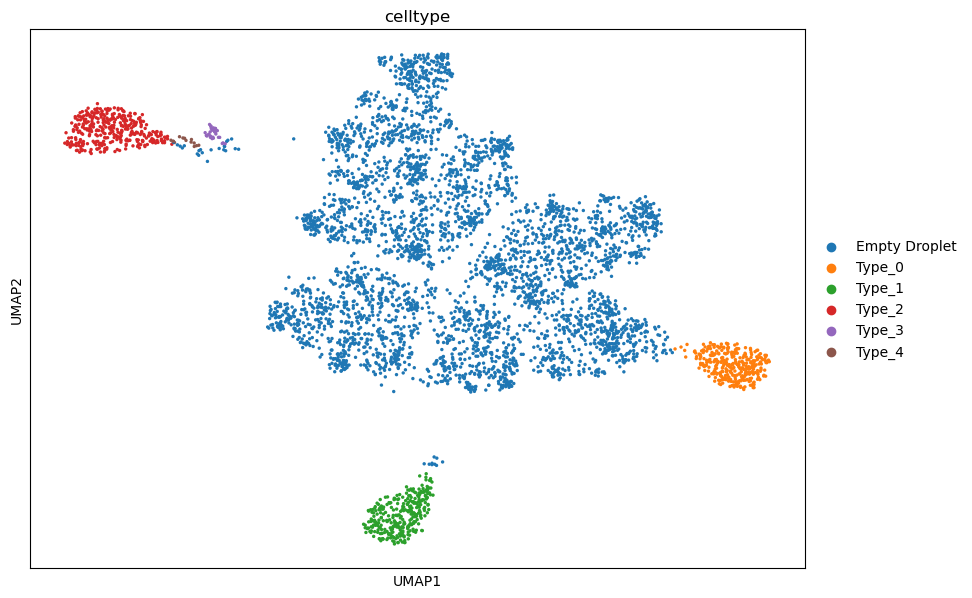

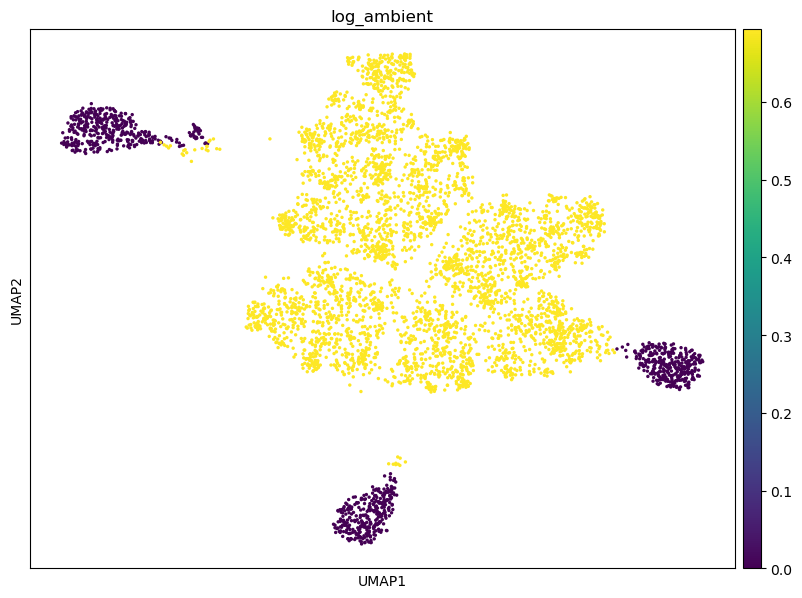

In [15]:
sc.pp.pca(data, n_comps=30)
sc.pp.neighbors(data, n_neighbors=30, n_pcs=30, knn=True)
sc.tl.umap(data)
fig, ax = plt.subplots(figsize=(10, 7))
sc.pl.umap(data, color='celltype', ax=ax)
fig, ax = plt.subplots(figsize=(10, 7))
sc.pl.umap(data, color='log_ambient', ax=ax)

In [16]:
denoised_data.obs[~denoised_data.obs["is_empty"]]

,celltype,is_empty,ambient_fraction,lib_size,cell_ambient_fraction,alpha_hat,z_hat
Cell_18,Type_2,False,0.000000,16148.779264,0.01,0.000129,3
Cell_19,Type_2,False,0.000000,6659.428810,0.01,0.000089,3
Cell_30,Type_1,False,0.000435,4013.363489,0.01,0.000131,2
Cell_31,Type_2,False,0.000000,6222.906934,0.01,0.000129,3
Cell_34,Type_1,False,0.000144,8550.956138,0.01,0.000090,2
...,...,...,...,...,...,...,...
Cell_4970,Type_2,False,0.000261,5603.595453,0.01,0.000151,3
Cell_4981,Type_2,False,0.000285,5386.356493,0.01,0.000146,3
Cell_4984,Type_0,False,0.000000,11245.953064,0.01,0.000082,1
Cell_4987,Type_0,False,0.000000,9517.929380,0.01,0.000147,1


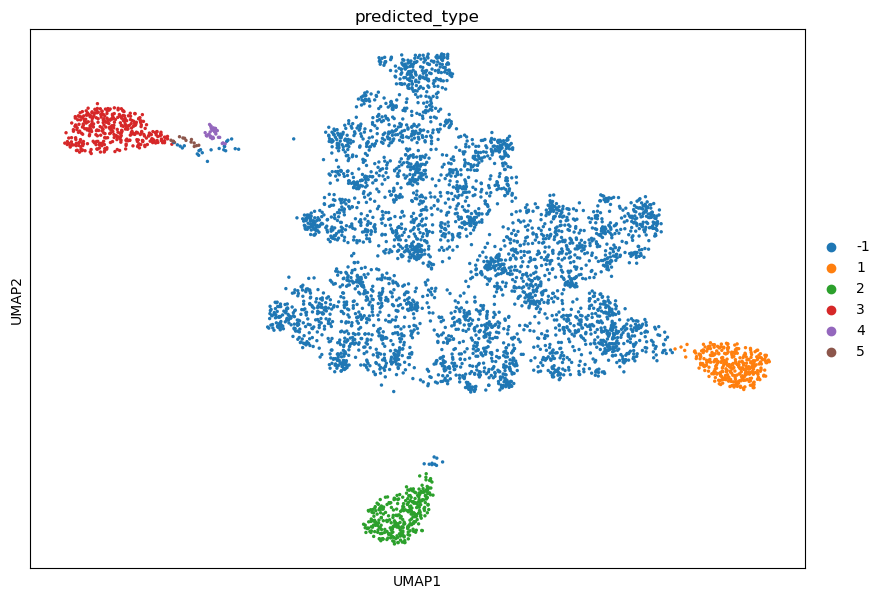

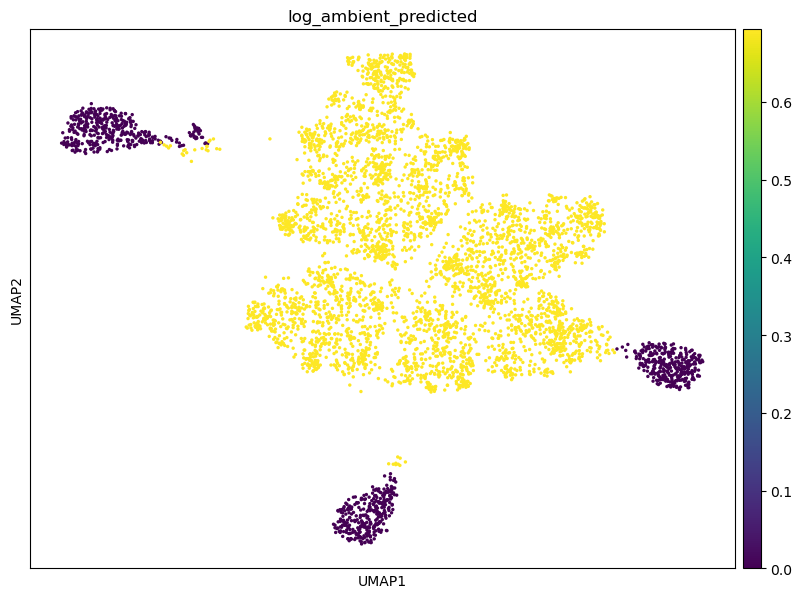

In [17]:
data.obs['log_ambient_predicted'] = np.log(denoised_data.obs['ambient_fraction']+1)
data.obs['predicted_type'] = denoised_data.obs['z_hat'].astype('category')

fig, ax = plt.subplots(figsize=(10, 7))
sc.pl.umap(data, color='predicted_type', ax=ax)
fig, ax = plt.subplots(figsize=(10, 7))
sc.pl.umap(data, color='log_ambient_predicted', ax=ax)